# Healthcare Operations & Patient Experience Decision Intelligence System

## Project Objective

This project analyzes hospital encounter data to identify patterns in
patient experience, operational performance, treatment utilization,
cost, length of stay, and 30-day readmission.

The analysis combines descriptive analytics, statistical testing,
and machine-learning techniques to generate actionable healthcare
management insights.

## Analytical Methodology

The project follows the following analytical workflow:

1. Data understanding and quality assessment
2. Data cleaning and transformation
3. Exploratory data analysis
4. Healthcare KPI analysis
5. Patient experience and operational analysis
6. Correlation analysis
7. Statistical hypothesis testing
8. 30-day readmission analysis
9. Predictive modeling
10. Model evaluation and comparison
11. Feature importance analysis
12. Healthcare management recommendations

# 1. Import Libraries

In [217]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [218]:
patient_df = pd.read_csv("../data/patient_encounters.csv")

# 3. Data Understanding

In [219]:
patient_df.head()

,Patient_ID,Visit_Date,Age,Gender,Department,Visit_Type,Diagnosis,Insurance,ICU_Admission,Number_of_Procedures,Waiting_Time_Min,Satisfaction_Score,Length_of_Stay,Treatment_Cost,Readmission_30_Days
0,P00001,2024-04-12,18,Male,Surgery,OPD,Infection,Yes,No,1,61.0,3.0,0.0,22262.0,0
1,P00002,2025-03-11,36,Male,Pediatrics,OPD,Hypertension,Yes,No,0,53.0,3.0,0.0,3149.0,0
2,P00003,2024-09-27,44,Male,Cardiology,OPD,Infection,Yes,No,0,19.0,3.0,0.0,13669.0,0
3,P00004,2024-04-16,31,Male,Surgery,OPD,Respiratory,No,No,1,73.0,3.0,0.0,23421.0,1
4,P00005,2024-03-12,40,Female,Cardiology,OPD,Diabetes,No,No,0,46.0,4.0,0.0,14231.0,0


In [220]:
patient_df.shape

(20000, 15)

In [221]:
patient_df.columns

Index(['Patient_ID', 'Visit_Date', 'Age', 'Gender', 'Department', 'Visit_Type',
       'Diagnosis', 'Insurance', 'ICU_Admission', 'Number_of_Procedures',
       'Waiting_Time_Min', 'Satisfaction_Score', 'Length_of_Stay',
       'Treatment_Cost', 'Readmission_30_Days'],
      dtype='str')

In [222]:
patient_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Patient_ID            20000 non-null  str    
 1   Visit_Date            20000 non-null  str    
 2   Age                   20000 non-null  int64  
 3   Gender                20000 non-null  str    
 4   Department            20000 non-null  str    
 5   Visit_Type            20000 non-null  str    
 6   Diagnosis             20000 non-null  str    
 7   Insurance             20000 non-null  str    
 8   ICU_Admission         20000 non-null  str    
 9   Number_of_Procedures  20000 non-null  int64  
 10  Waiting_Time_Min      20000 non-null  float64
 11  Satisfaction_Score    20000 non-null  float64
 12  Length_of_Stay        20000 non-null  float64
 13  Treatment_Cost        20000 non-null  float64
 14  Readmission_30_Days   20000 non-null  int64  
dtypes: float64(4), int64(3), str(8

In [223]:
patient_df.describe()

,Age,Number_of_Procedures,Waiting_Time_Min,Satisfaction_Score,Length_of_Stay,Treatment_Cost,Readmission_30_Days
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,45.538650,1.510150,38.361250,3.678850,0.779300,25673.777850,0.070300
std,16.810917,1.231736,17.476058,0.894121,2.104166,16074.852183,0.255658
min,18.000000,0.000000,5.000000,1.000000,0.000000,1000.000000,0.000000
25%,33.000000,1.000000,26.000000,3.000000,0.000000,14470.250000,0.000000
50%,45.000000,1.000000,38.000000,4.000000,0.000000,21915.000000,0.000000
75%,57.000000,2.000000,50.000000,4.000000,0.000000,32399.500000,0.000000
max,90.000000,8.000000,107.000000,5.000000,20.000000,136892.000000,1.000000


In [224]:
patient_df.isnull().sum()

Patient_ID              0
Visit_Date              0
Age                     0
Gender                  0
Department              0
Visit_Type              0
Diagnosis               0
Insurance               0
ICU_Admission           0
Number_of_Procedures    0
Waiting_Time_Min        0
Satisfaction_Score      0
Length_of_Stay          0
Treatment_Cost          0
Readmission_30_Days     0
dtype: int64

In [225]:
patient_df.duplicated().sum()

np.int64(0)

In [227]:
patient_df["Visit_Date"] = pd.to_datetime(patient_df["Visit_Date"])

In [228]:
patient_df["Visit_Date"].dtype

dtype('<M8[us]')

In [229]:
patient_df["Visit_Date"].min()

Timestamp('2024-01-01 00:00:00')

In [230]:
patient_df["Visit_Date"].max()

Timestamp('2025-12-30 00:00:00')

In [231]:
patient_df["Year"] = patient_df["Visit_Date"].dt.year

In [232]:
patient_df["Month"] = patient_df["Visit_Date"].dt.month

In [235]:
patient_df["Gender"].value_counts()

Gender
Female    10031
Male       9969
Name: count, dtype: int64

In [236]:
patient_df["Department"].value_counts()

Department
General Medicine    4310
Orthopedics         3003
Gynecology          2860
Surgery             2755
Cardiology          2628
Pediatrics          2523
Dermatology         1921
Name: count, dtype: int64

In [237]:
patient_df["Visit_Type"].value_counts()

Visit_Type
OPD    16439
IPD     3561
Name: count, dtype: int64

In [238]:
patient_df["Insurance"].value_counts()

Insurance
Yes    10968
No      9032
Name: count, dtype: int64

In [239]:
patient_df["Patient_ID"].nunique()

20000

# 4. Exploratory Data Analysis

In [240]:
department_volume = patient_df["Department"].value_counts()

department_volume

Department
General Medicine    4310
Orthopedics         3003
Gynecology          2860
Surgery             2755
Cardiology          2628
Pediatrics          2523
Dermatology         1921
Name: count, dtype: int64

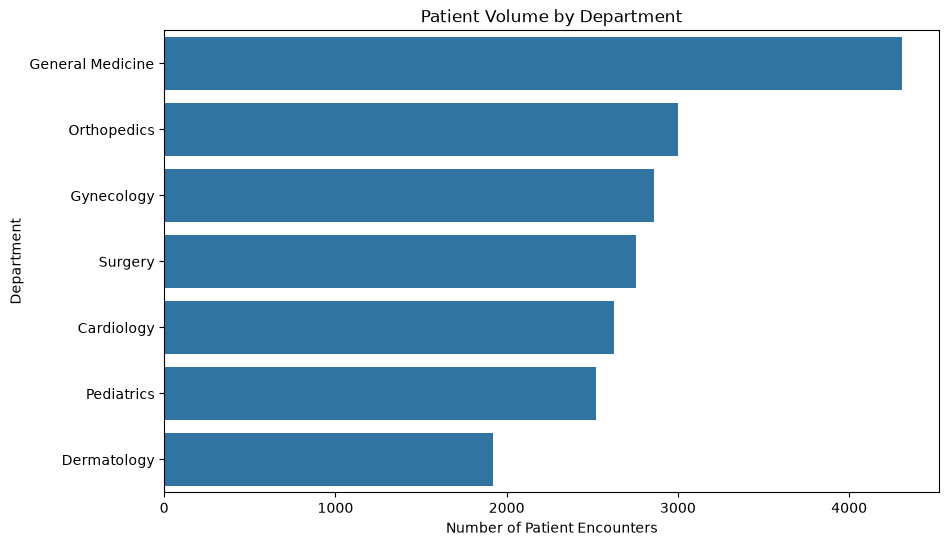

In [241]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=department_volume.values,
    y=department_volume.index
)

plt.title("Patient Volume by Department")
plt.xlabel("Number of Patient Encounters")
plt.ylabel("Department")

plt.show()

In [242]:
monthly_volume = patient_df.groupby(
    ["Year", "Month"]
).size()

monthly_volume

Year  Month
2024  1        867
      2        757
      3        874
      4        843
      5        821
      6        829
      7        839
      8        870
      9        844
      10       834
      11       788
      12       798
2025  1        878
      2        736
      3        846
      4        802
      5        828
      6        852
      7        875
      8        851
      9        823
      10       904
      11       827
      12       814
dtype: int64

In [243]:
monthly_volume = monthly_volume.reset_index(name="Patient_Volume")

monthly_volume

,Year,Month,Patient_Volume
0,2024,1,867
1,2024,2,757
2,2024,3,874
3,2024,4,843
4,2024,5,821
5,2024,6,829
6,2024,7,839
7,2024,8,870
8,2024,9,844
9,2024,10,834


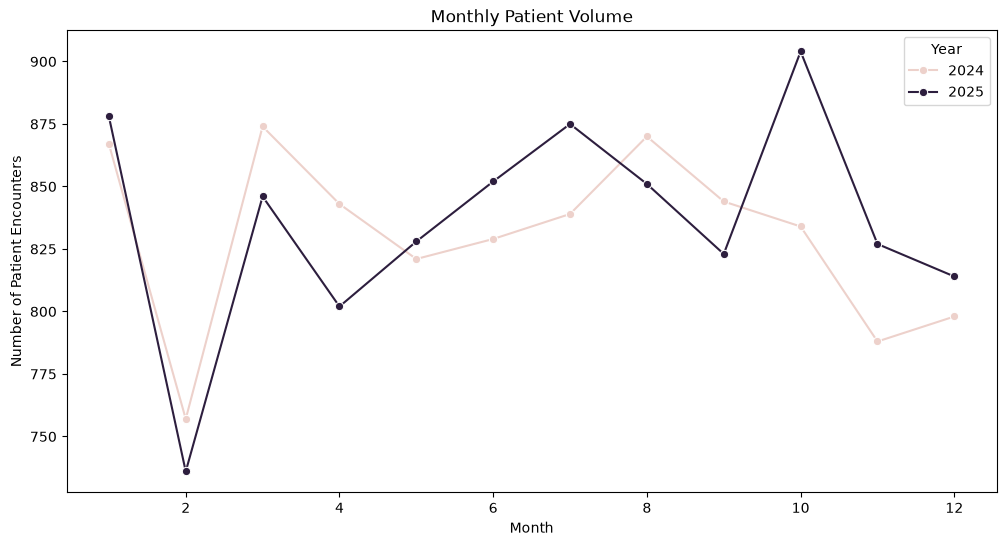

In [244]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_volume,
    x="Month",
    y="Patient_Volume",
    hue="Year",
    marker="o"
)

plt.title("Monthly Patient Volume")
plt.xlabel("Month")
plt.ylabel("Number of Patient Encounters")

plt.show()

## 4.1 Patient Experience & Waiting Time

In [245]:
patient_df["Waiting_Time_Min"].describe()

count    20000.000000
mean        38.361250
std         17.476058
min          5.000000
25%         26.000000
50%         38.000000
75%         50.000000
max        107.000000
Name: Waiting_Time_Min, dtype: float64

In [246]:
waiting_by_department = patient_df.groupby(
    "Department"
)["Waiting_Time_Min"].mean().sort_values(ascending=False)

waiting_by_department

Department
Cardiology          38.586377
Orthopedics         38.549784
General Medicine    38.475406
Surgery             38.383666
Gynecology          38.306993
Dermatology         38.015096
Pediatrics          38.007927
Name: Waiting_Time_Min, dtype: float64

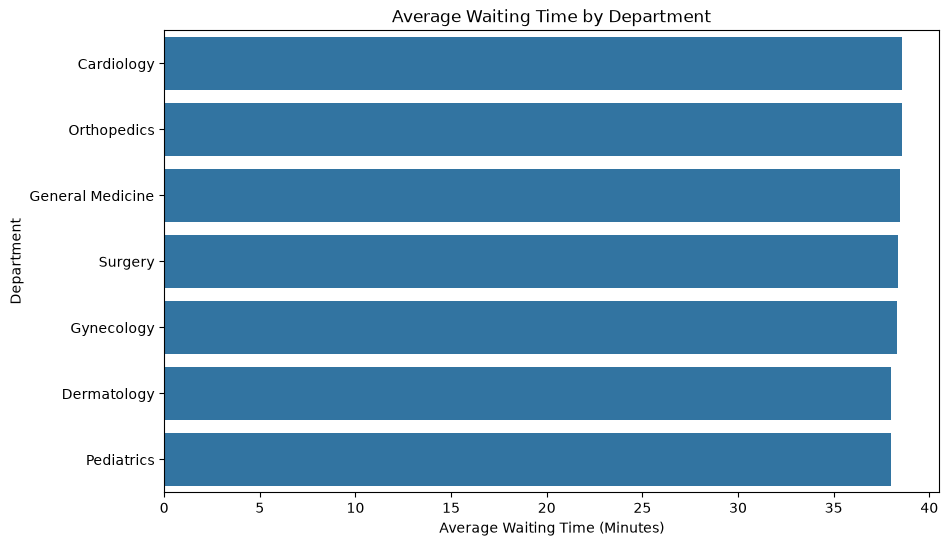

In [247]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=waiting_by_department.values,
    y=waiting_by_department.index
)

plt.title("Average Waiting Time by Department")
plt.xlabel("Average Waiting Time (Minutes)")
plt.ylabel("Department")

plt.show()

In [248]:
patient_df["Satisfaction_Score"].describe()

count    20000.000000
mean         3.678850
std          0.894121
min          1.000000
25%          3.000000
50%          4.000000
75%          4.000000
max          5.000000
Name: Satisfaction_Score, dtype: float64

In [249]:
satisfaction_by_department = patient_df.groupby(
    "Department"
)["Satisfaction_Score"].mean().sort_values(ascending=False)

satisfaction_by_department

Department
Pediatrics          3.696790
Orthopedics         3.682318
General Medicine    3.680510
Gynecology          3.680070
Dermatology         3.676210
Cardiology          3.668189
Surgery             3.666788
Name: Satisfaction_Score, dtype: float64

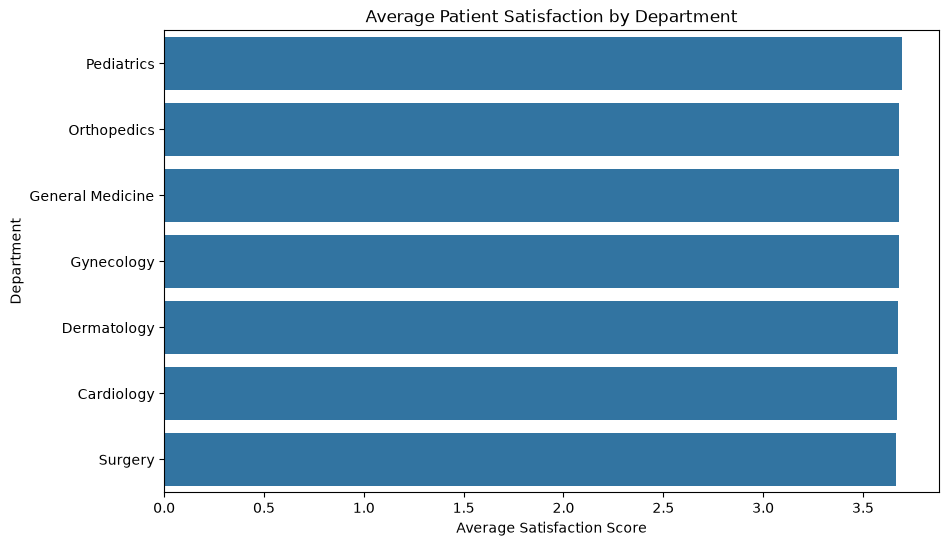

In [250]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=satisfaction_by_department.values,
    y=satisfaction_by_department.index
)

plt.title("Average Patient Satisfaction by Department")
plt.xlabel("Average Satisfaction Score")
plt.ylabel("Department")

plt.show()

In [252]:
patient_df["Waiting_Time_Min"].corr(
    patient_df["Satisfaction_Score"]
)

np.float64(-0.0036758279067812287)

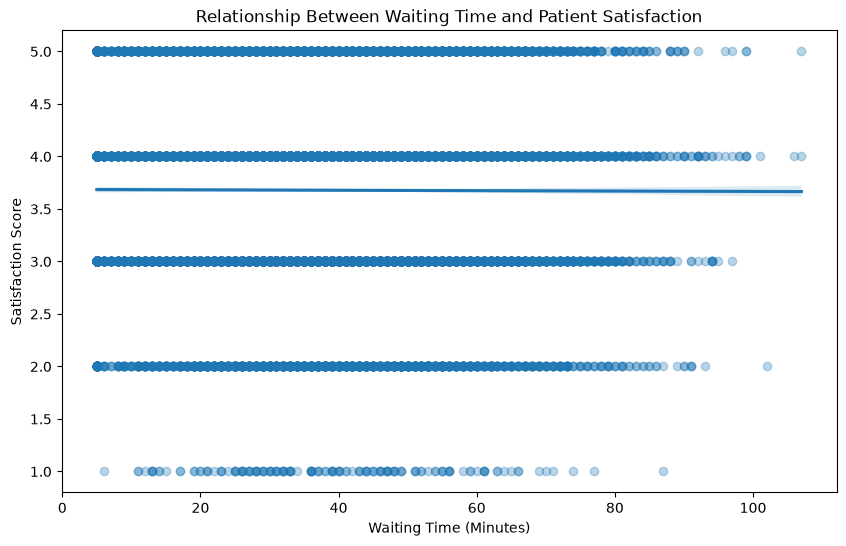

In [253]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=patient_df,
    x="Waiting_Time_Min",
    y="Satisfaction_Score",
    scatter_kws={"alpha": 0.3}
)

plt.title("Relationship Between Waiting Time and Patient Satisfaction")
plt.xlabel("Waiting Time (Minutes)")
plt.ylabel("Satisfaction Score")

plt.show()

## 4.2 Length of Stay & Treatment Cost

In [254]:
patient_df["Length_of_Stay"].describe()

count    20000.000000
mean         0.779300
std          2.104166
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         20.000000
Name: Length_of_Stay, dtype: float64

In [255]:
los_by_department = patient_df.groupby(
    "Department"
)["Length_of_Stay"].mean().sort_values(ascending=False)

los_by_department

Department
Orthopedics         0.845821
Pediatrics          0.808561
Dermatology         0.770432
Cardiology          0.768265
Surgery             0.765880
Gynecology          0.757343
General Medicine    0.749652
Name: Length_of_Stay, dtype: float64

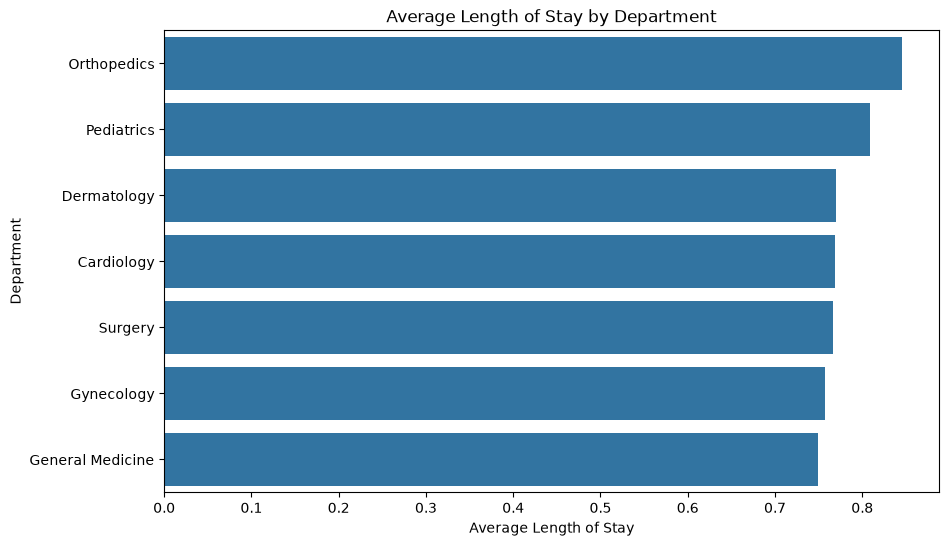

In [256]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=los_by_department.values,
    y=los_by_department.index
)

plt.title("Average Length of Stay by Department")
plt.xlabel("Average Length of Stay")
plt.ylabel("Department")

plt.show()

In [257]:
patient_df["Treatment_Cost"].describe()

count     20000.000000
mean      25673.777850
std       16074.852183
min        1000.000000
25%       14470.250000
50%       21915.000000
75%       32399.500000
max      136892.000000
Name: Treatment_Cost, dtype: float64

In [258]:
cost_by_department = patient_df.groupby(
    "Department"
)["Treatment_Cost"].mean().sort_values(ascending=False)

cost_by_department

Department
Surgery             31453.788385
Cardiology          30516.805556
Orthopedics         27256.108891
Gynecology          24424.835315
General Medicine    22687.324362
Pediatrics          22414.611970
Dermatology         21125.792296
Name: Treatment_Cost, dtype: float64

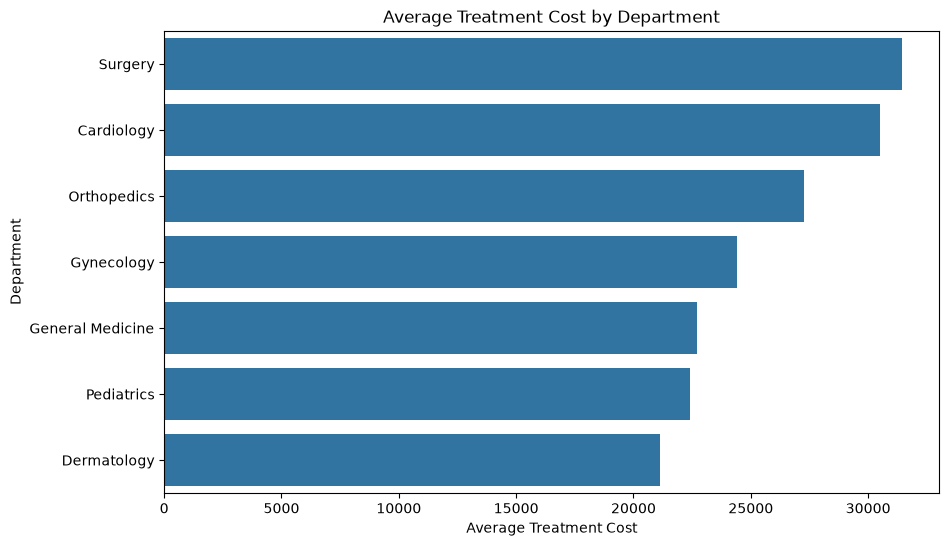

In [259]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=cost_by_department.values,
    y=cost_by_department.index
)

plt.title("Average Treatment Cost by Department")
plt.xlabel("Average Treatment Cost")
plt.ylabel("Department")

plt.show()

In [260]:
patient_df["Length_of_Stay"].corr(
    patient_df["Treatment_Cost"]
)

np.float64(0.553411974301516)

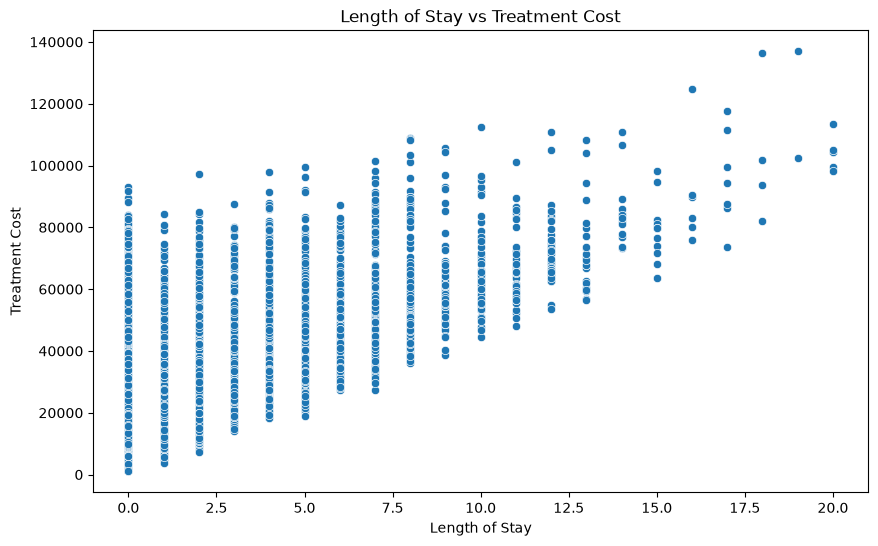

In [261]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=patient_df,
    x="Length_of_Stay",
    y="Treatment_Cost"
)

plt.title("Length of Stay vs Treatment Cost")
plt.xlabel("Length of Stay")
plt.ylabel("Treatment Cost")

plt.show()

## 4.3 Readmission Overview

In [262]:
patient_df["Readmission_30_Days"].value_counts()

Readmission_30_Days
0    18594
1     1406
Name: count, dtype: int64

In [264]:
readmission_rate = (
    patient_df["Readmission_30_Days"].mean() * 100
)

readmission_rate

np.float64(7.03)

In [265]:
readmission_by_department = (
    patient_df.groupby("Department")["Readmission_30_Days"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

readmission_by_department

Department
Dermatology         8.485164
Pediatrics          7.213635
General Medicine    7.169374
Orthopedics         7.026307
Gynecology          6.958042
Cardiology          6.697108
Surgery             6.025408
Name: Readmission_30_Days, dtype: float64

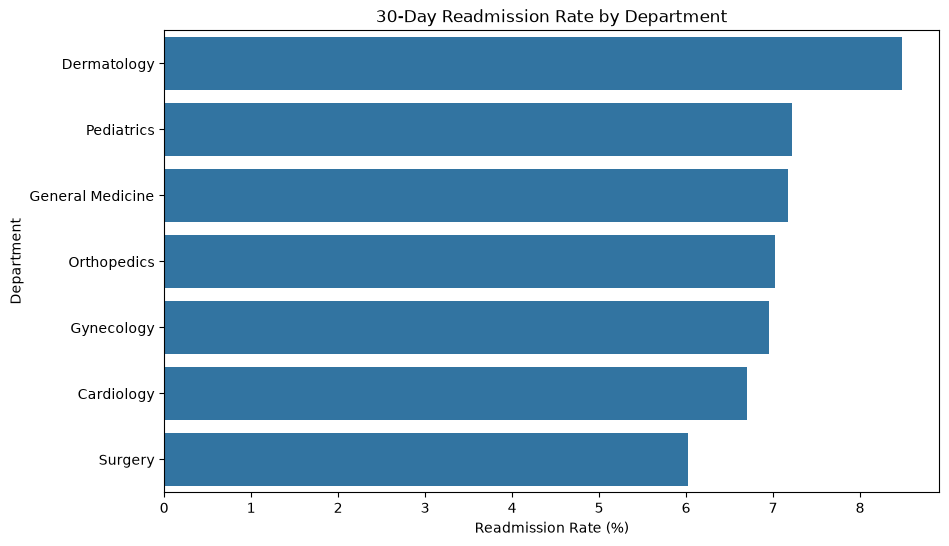

In [266]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=readmission_by_department.values,
    y=readmission_by_department.index
)

plt.title("30-Day Readmission Rate by Department")
plt.xlabel("Readmission Rate (%)")
plt.ylabel("Department")

plt.show()

## 4.4 ICU Admission

In [267]:
patient_df["ICU_Admission"].value_counts()

ICU_Admission
No     18344
Yes     1656
Name: count, dtype: int64

In [269]:
icu_rate = (
    (patient_df["ICU_Admission"] == "Yes").sum()
    / patient_df["ICU_Admission"].notna().sum()
) * 100

icu_rate

np.float64(8.28)

In [270]:
icu_by_department = (
    patient_df.groupby("Department")["ICU_Admission"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

icu_by_department

Department
Cardiology          9.665145
Dermatology         8.693389
Pediatrics          8.481966
Orthopedics         8.258408
Gynecology          8.041958
General Medicine    7.958237
Surgery             7.259528
Name: ICU_Admission, dtype: float64

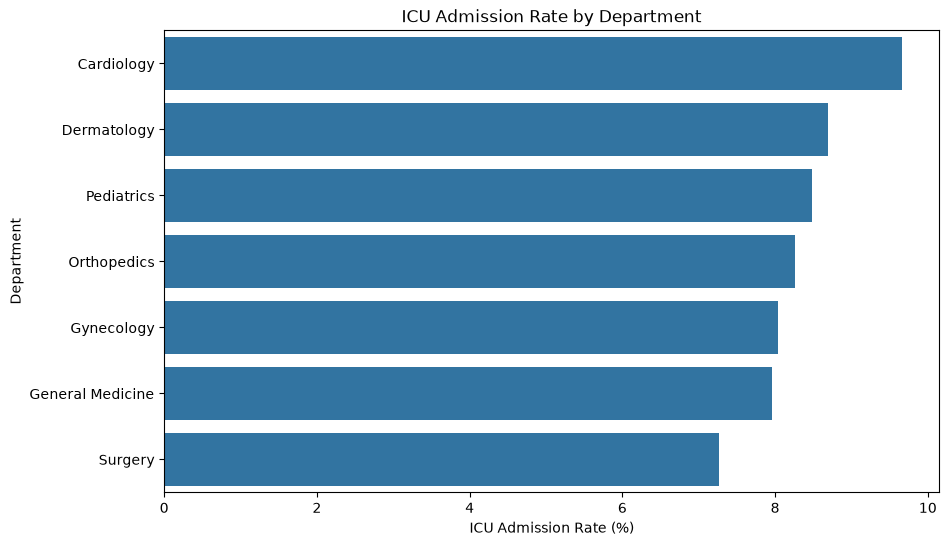

In [271]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=icu_by_department.values,
    y=icu_by_department.index
)

plt.title("ICU Admission Rate by Department")
plt.xlabel("ICU Admission Rate (%)")
plt.ylabel("Department")

plt.show()

## 4.5 Treatment Utilization

In [272]:
patient_df["Number_of_Procedures"].describe()

count    20000.000000
mean         1.510150
std          1.231736
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: Number_of_Procedures, dtype: float64

In [273]:
procedures_by_department = (
    patient_df.groupby("Department")["Number_of_Procedures"]
    .mean()
    .sort_values(ascending=False)
)

procedures_by_department

Department
Pediatrics          1.542212
Cardiology          1.523212
Gynecology          1.518531
Orthopedics         1.507160
Surgery             1.498367
General Medicine    1.496984
Dermatology         1.488808
Name: Number_of_Procedures, dtype: float64

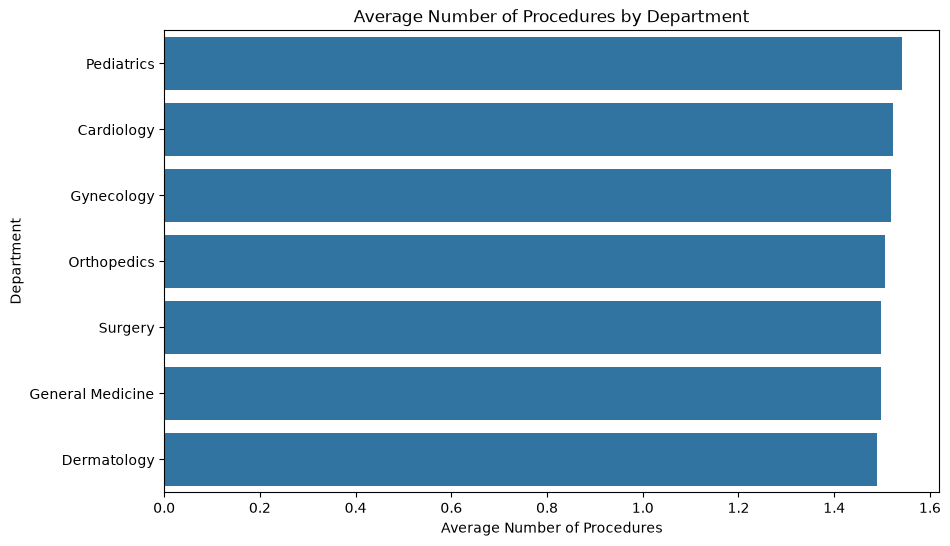

In [274]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=procedures_by_department.values,
    y=procedures_by_department.index
)

plt.title("Average Number of Procedures by Department")
plt.xlabel("Average Number of Procedures")
plt.ylabel("Department")

plt.show()

In [275]:
patient_df["Number_of_Procedures"].corr(
    patient_df["Treatment_Cost"]
)

np.float64(0.4979513272804489)

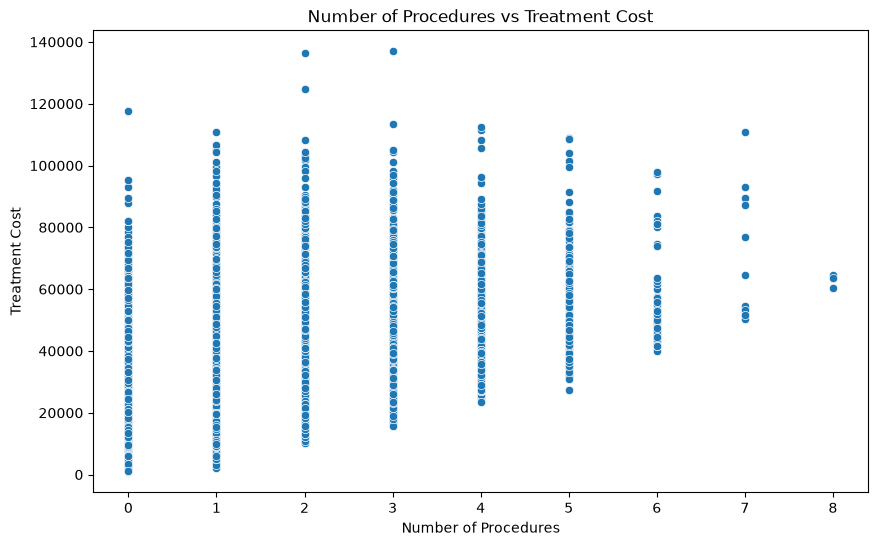

In [276]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=patient_df,
    x="Number_of_Procedures",
    y="Treatment_Cost"
)

plt.title("Number of Procedures vs Treatment Cost")
plt.xlabel("Number of Procedures")
plt.ylabel("Treatment Cost")

plt.show()

## 4.6 Visit Type Analysis

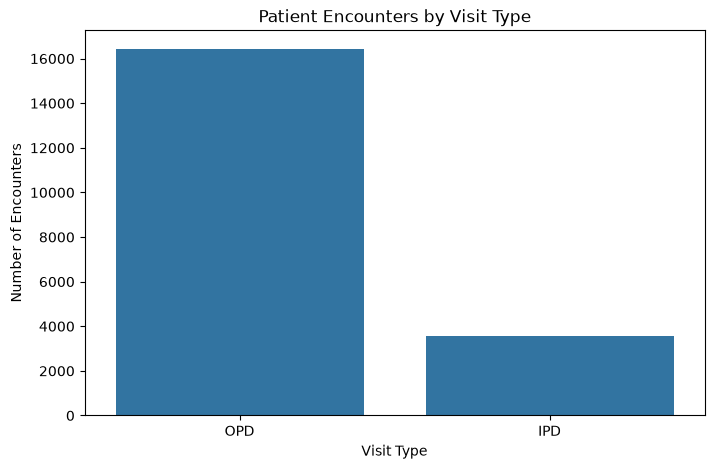

In [279]:
visit_type_counts = patient_df["Visit_Type"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=visit_type_counts.index,
    y=visit_type_counts.values
)

plt.title("Patient Encounters by Visit Type")
plt.xlabel("Visit Type")
plt.ylabel("Number of Encounters")

plt.show()

In [280]:
cost_by_visit_type = (
    patient_df.groupby("Visit_Type")["Treatment_Cost"]
    .mean()
    .sort_values(ascending=False)
)

cost_by_visit_type

Visit_Type
IPD    40989.033698
OPD    22356.202202
Name: Treatment_Cost, dtype: float64

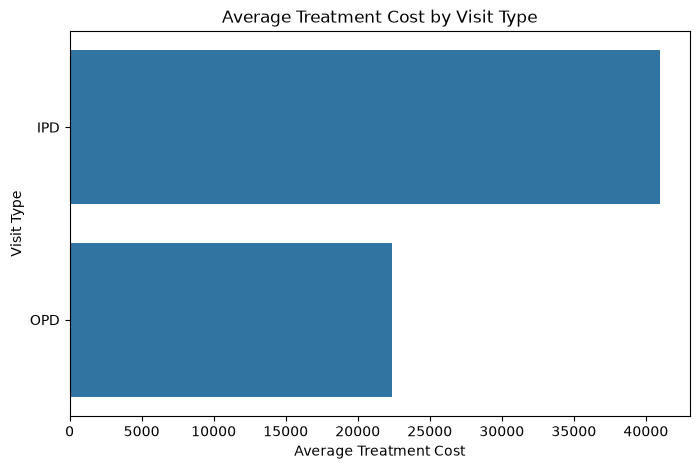

In [281]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cost_by_visit_type.values,
    y=cost_by_visit_type.index
)

plt.title("Average Treatment Cost by Visit Type")
plt.xlabel("Average Treatment Cost")
plt.ylabel("Visit Type")

plt.show()

In [282]:
los_by_visit_type = (
    patient_df.groupby("Visit_Type")["Length_of_Stay"]
    .mean()
    .sort_values(ascending=False)
)

los_by_visit_type

Visit_Type
IPD    4.37686
OPD    0.00000
Name: Length_of_Stay, dtype: float64

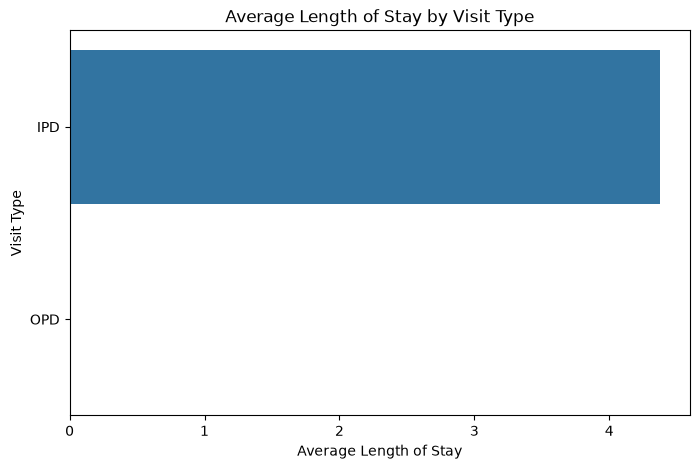

In [283]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=los_by_visit_type.values,
    y=los_by_visit_type.index
)

plt.title("Average Length of Stay by Visit Type")
plt.xlabel("Average Length of Stay")
plt.ylabel("Visit Type")

plt.show()

## 4.7 Diagnosis Analysis

In [288]:
top_diagnoses = patient_df["Diagnosis"].value_counts().head(10)

top_diagnoses

Diagnosis
Infection       2557
Diabetes        2533
Respiratory     2530
Fracture        2511
Gastric         2487
Hypertension    2483
Cardiac         2473
Other           2426
Name: count, dtype: int64

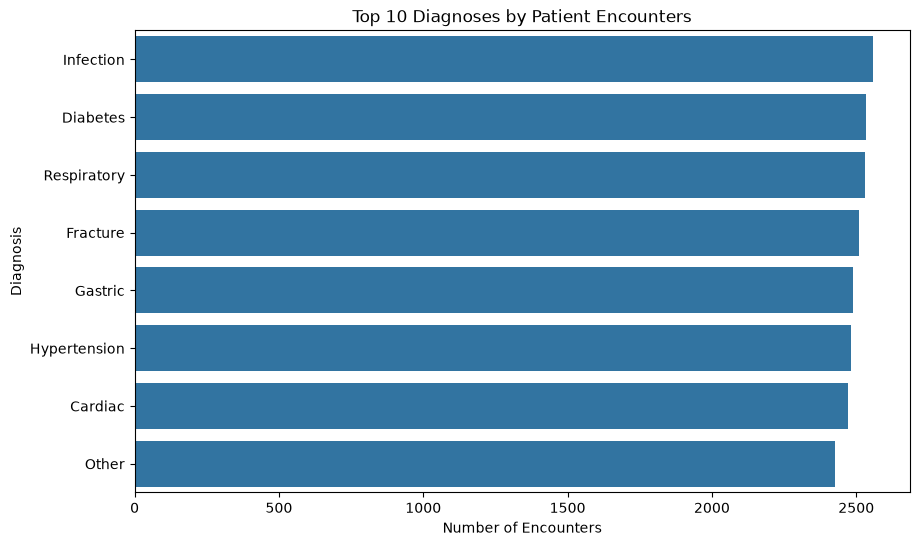

In [289]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_diagnoses.values,
    y=top_diagnoses.index
)

plt.title("Top 10 Diagnoses by Patient Encounters")
plt.xlabel("Number of Encounters")
plt.ylabel("Diagnosis")

plt.show()

In [290]:
cost_by_diagnosis = (
    patient_df.groupby("Diagnosis")["Treatment_Cost"]
    .mean()
    .sort_values(ascending=False)
)

cost_by_diagnosis

Diagnosis
Respiratory     25967.075494
Infection       25850.504889
Gastric         25808.675513
Other           25765.247321
Diabetes        25741.566917
Hypertension    25610.067257
Cardiac         25462.351799
Fracture        25179.158503
Name: Treatment_Cost, dtype: float64

In [291]:
top_cost_diagnoses = cost_by_diagnosis.head(10)

top_cost_diagnoses

Diagnosis
Respiratory     25967.075494
Infection       25850.504889
Gastric         25808.675513
Other           25765.247321
Diabetes        25741.566917
Hypertension    25610.067257
Cardiac         25462.351799
Fracture        25179.158503
Name: Treatment_Cost, dtype: float64

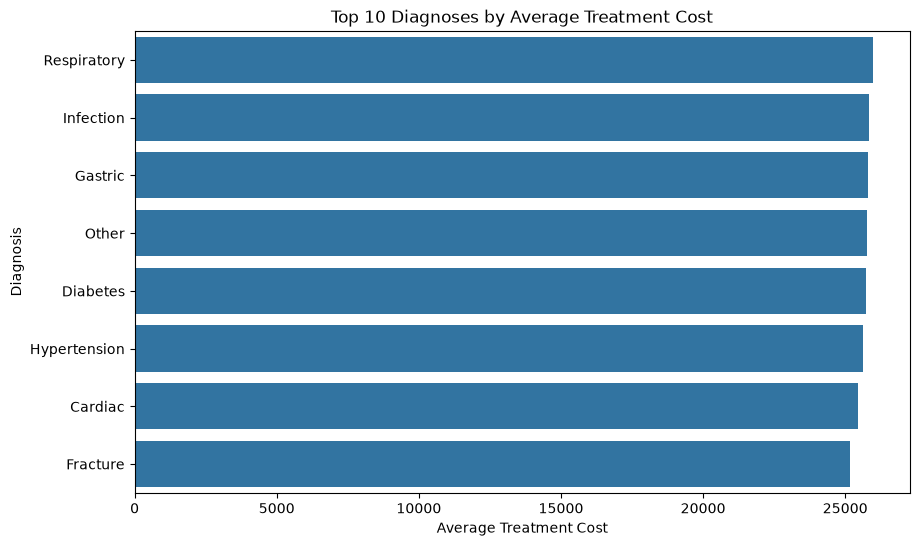

In [292]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_cost_diagnoses.values,
    y=top_cost_diagnoses.index
)

plt.title("Top 10 Diagnoses by Average Treatment Cost")
plt.xlabel("Average Treatment Cost")
plt.ylabel("Diagnosis")

plt.show()

In [293]:
diagnosis_by_department = pd.crosstab(
    patient_df["Department"],
    patient_df["Diagnosis"]
)

diagnosis_by_department

Diagnosis,Cardiac,Diabetes,Fracture,Gastric,Hypertension,Infection,Other,Respiratory
Department,,,,,,,,
Cardiology,323,347,332,330,304,332,315,345
Dermatology,239,249,246,223,217,245,257,245
General Medicine,531,533,525,568,555,528,518,552
Gynecology,356,364,354,356,368,369,336,357
Orthopedics,353,390,392,363,384,390,359,372
Pediatrics,353,310,312,284,309,354,289,312
Surgery,318,340,350,363,346,339,352,347


In [294]:
dominant_diagnosis = diagnosis_by_department.idxmax(axis=1)

dominant_diagnosis

Department
Cardiology           Diabetes
Dermatology             Other
General Medicine      Gastric
Gynecology          Infection
Orthopedics          Fracture
Pediatrics          Infection
Surgery               Gastric
dtype: str

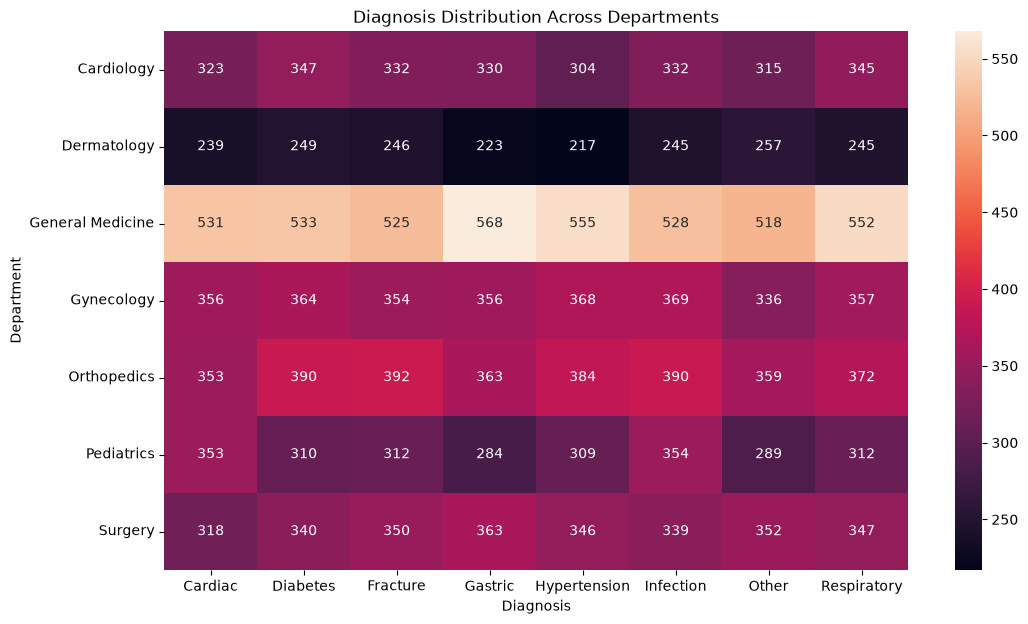

In [295]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    diagnosis_by_department,
    annot=True,
    fmt="d"
)

plt.title("Diagnosis Distribution Across Departments")
plt.xlabel("Diagnosis")
plt.ylabel("Department")

plt.show()

In [296]:
diagnosis_share = pd.crosstab(
    patient_df["Department"],
    patient_df["Diagnosis"],
    normalize="index"
) * 100

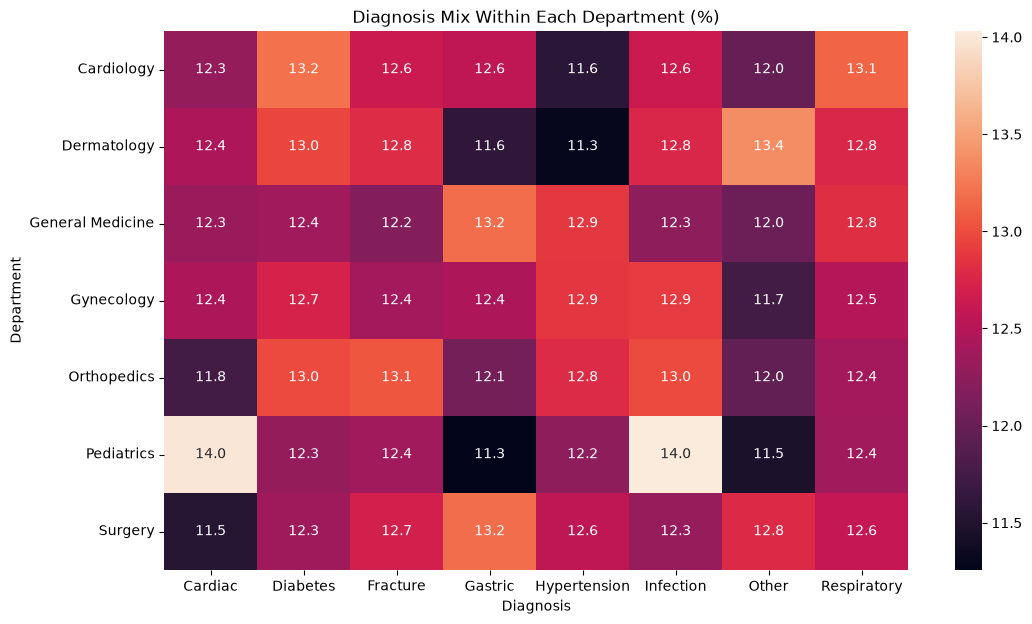

In [297]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    diagnosis_share,
    annot=True,
    fmt=".1f"
)

plt.title("Diagnosis Mix Within Each Department (%)")
plt.xlabel("Diagnosis")
plt.ylabel("Department")

plt.show()

## 4.8 Demographic & Insurance Analysis

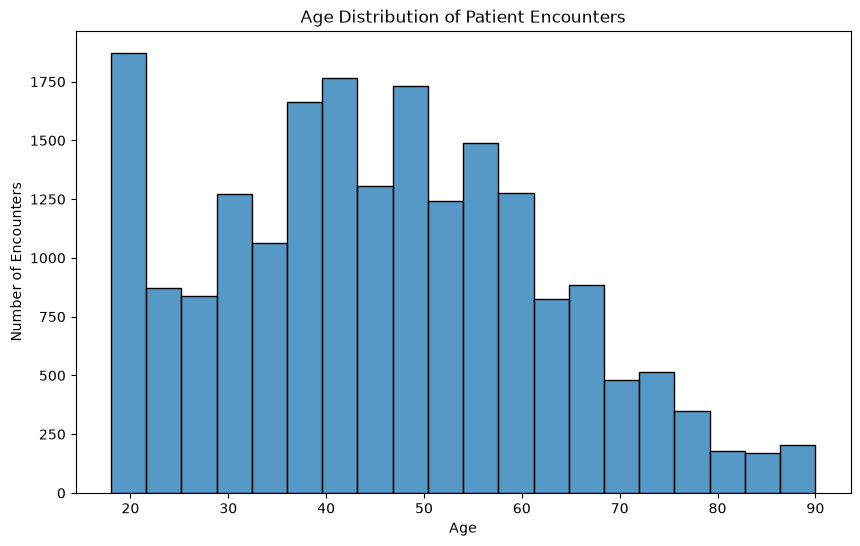

In [299]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=patient_df,
    x="Age",
    bins=20
)

plt.title("Age Distribution of Patient Encounters")
plt.xlabel("Age")
plt.ylabel("Number of Encounters")

plt.show()

In [300]:
gender_counts = patient_df["Gender"].value_counts()

gender_counts

Gender
Female    10031
Male       9969
Name: count, dtype: int64

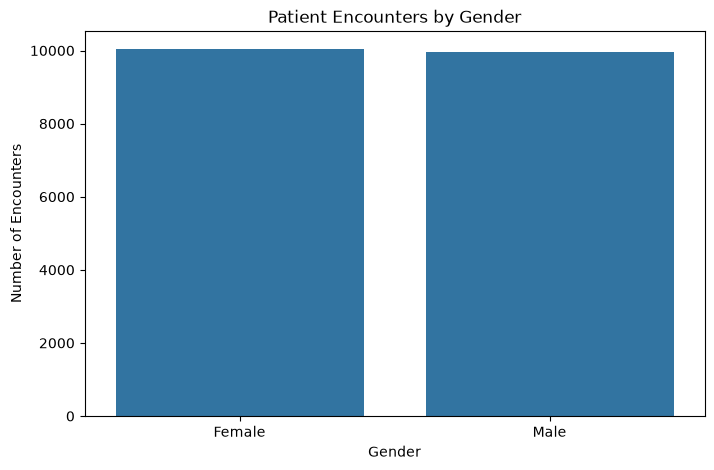

In [302]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Patient Encounters by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Encounters")

plt.show()

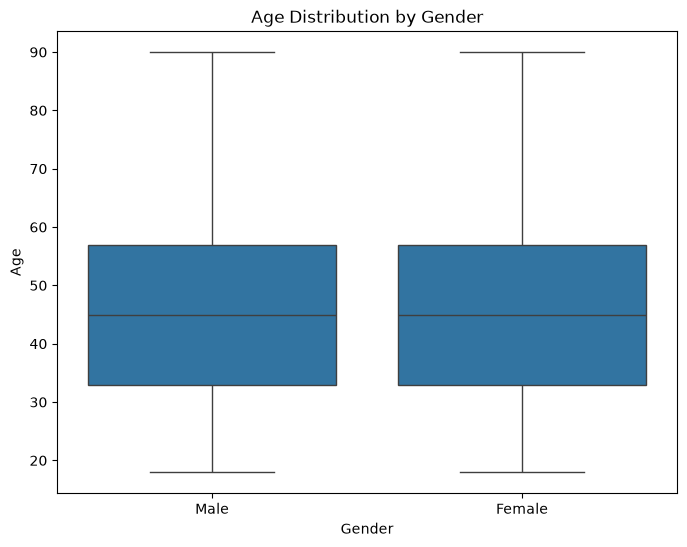

In [303]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=patient_df,
    x="Gender",
    y="Age"
)

plt.title("Age Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Age")

plt.show()

In [304]:
insurance_counts = patient_df["Insurance"].value_counts()

insurance_counts

Insurance
Yes    10968
No      9032
Name: count, dtype: int64

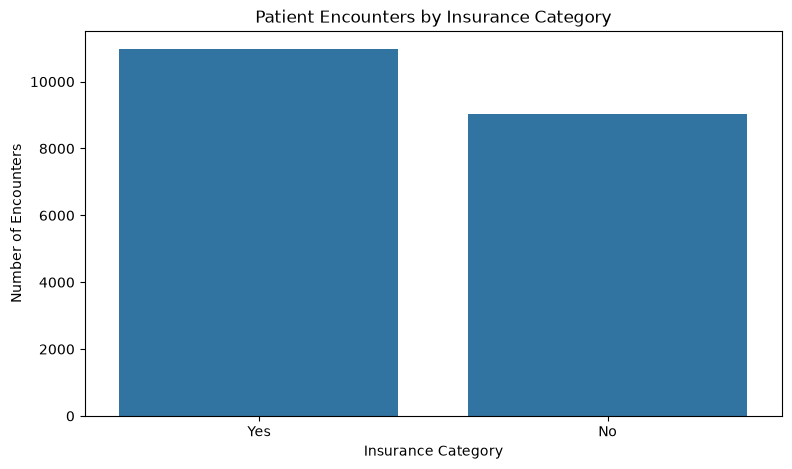

In [306]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=insurance_counts.index,
    y=insurance_counts.values
)

plt.title("Patient Encounters by Insurance Category")
plt.xlabel("Insurance Category")
plt.ylabel("Number of Encounters")

plt.show()

In [307]:
cost_by_insurance = (
    patient_df.groupby("Insurance")["Treatment_Cost"]
    .mean()
    .sort_values(ascending=False)
)

cost_by_insurance


Insurance
Yes    25715.407732
No     25623.224646
Name: Treatment_Cost, dtype: float64

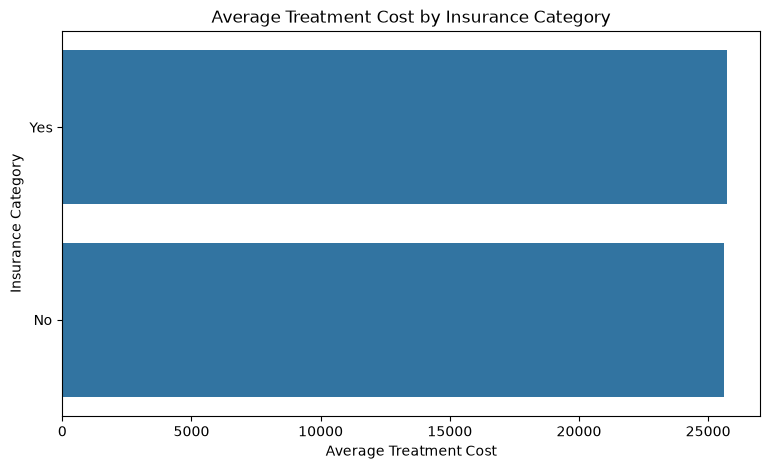

In [308]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=cost_by_insurance.values,
    y=cost_by_insurance.index
)

plt.title("Average Treatment Cost by Insurance Category")
plt.xlabel("Average Treatment Cost")
plt.ylabel("Insurance Category")

plt.show()

# 5. Correlation Analysis

In [310]:
numeric_kpis = [
    "Age",
    "Waiting_Time_Min",
    "Satisfaction_Score",
    "Length_of_Stay",
    "Treatment_Cost",
    "Number_of_Procedures",
    "Readmission_30_Days"
]

correlation_matrix = patient_df[numeric_kpis].corr()

correlation_matrix

,Age,Waiting_Time_Min,Satisfaction_Score,Length_of_Stay,Treatment_Cost,Number_of_Procedures,Readmission_30_Days
Age,1.000000,-0.000233,-0.006192,0.002298,0.009046,0.001923,0.086032
Waiting_Time_Min,-0.000233,1.000000,-0.003676,0.001186,0.004446,0.001805,0.010431
Satisfaction_Score,-0.006192,-0.003676,1.000000,-0.001211,-0.006804,-0.004917,0.009305
Length_of_Stay,0.002298,0.001186,-0.001211,1.000000,0.553412,0.002716,0.062305
Treatment_Cost,0.009046,0.004446,-0.006804,0.553412,1.000000,0.497951,0.048845
Number_of_Procedures,0.001923,0.001805,-0.004917,0.002716,0.497951,1.000000,-0.007824
Readmission_30_Days,0.086032,0.010431,0.009305,0.062305,0.048845,-0.007824,1.000000


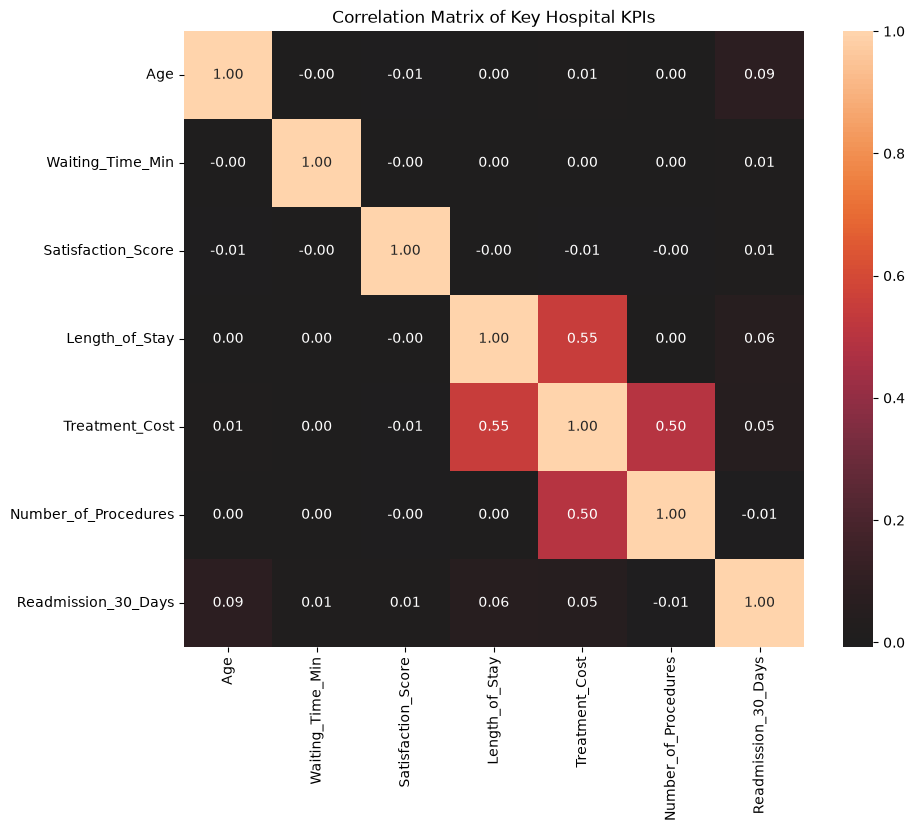

In [311]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Matrix of Key Hospital KPIs")

plt.show()

### Correlation Findings

- Length of Stay and Treatment Cost showed the strongest positive association (r = 0.55).
- Number of Procedures and Treatment Cost showed a moderate positive association (r = 0.50).
- Waiting Time and Satisfaction Score showed essentially no linear association (r ≈ 0.00).
- Age and 30-Day Readmission showed a very weak positive association (r = 0.09).
- Length of Stay and Number of Procedures showed virtually no linear association (r ≈ 0.00).

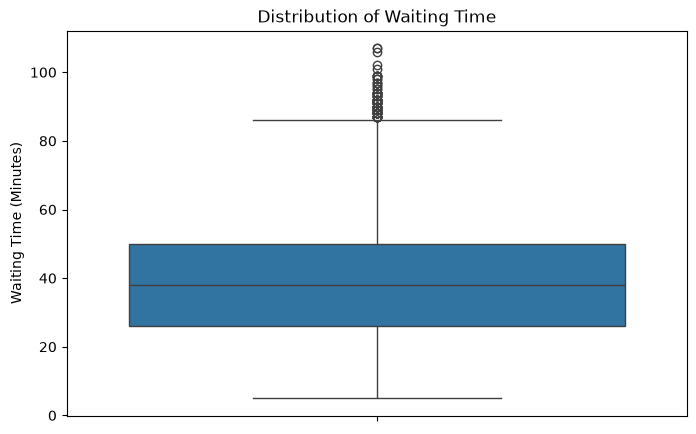

In [312]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    y=patient_df["Waiting_Time_Min"]
)

plt.title("Distribution of Waiting Time")
plt.ylabel("Waiting Time (Minutes)")

plt.show()

# 6. Analysis Dataset Preparation

In [321]:
analysis_df = patient_df.copy()

In [324]:
analysis_df[
    [
        "Age",
        "Waiting_Time_Min",
        "Satisfaction_Score",
        "Length_of_Stay",
        "Treatment_Cost",
        "Number_of_Procedures",
        "Readmission_30_Days"
    ]
].describe()

,Age,Waiting_Time_Min,Satisfaction_Score,Length_of_Stay,Treatment_Cost,Number_of_Procedures,Readmission_30_Days
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,45.538650,38.361250,3.678850,0.779300,25673.777850,1.510150,0.070300
std,16.810917,17.476058,0.894121,2.104166,16074.852183,1.231736,0.255658
min,18.000000,5.000000,1.000000,0.000000,1000.000000,0.000000,0.000000
25%,33.000000,26.000000,3.000000,0.000000,14470.250000,1.000000,0.000000
50%,45.000000,38.000000,4.000000,0.000000,21915.000000,1.000000,0.000000
75%,57.000000,50.000000,4.000000,0.000000,32399.500000,2.000000,0.000000
max,90.000000,107.000000,5.000000,20.000000,136892.000000,8.000000,1.000000


## 6.1 Derived Analytical Variables

In [325]:
analysis_df["Age_Group"] = pd.cut(
    analysis_df["Age"],
    bins=[0, 17, 39, 59, 120],
    labels=["0-17", "18-39", "40-59", "60+"]
)

In [326]:
analysis_df["Age_Group"].value_counts().sort_index()

Age_Group
0-17        0
18-39    7583
40-59    8200
60+      4217
Name: count, dtype: int64

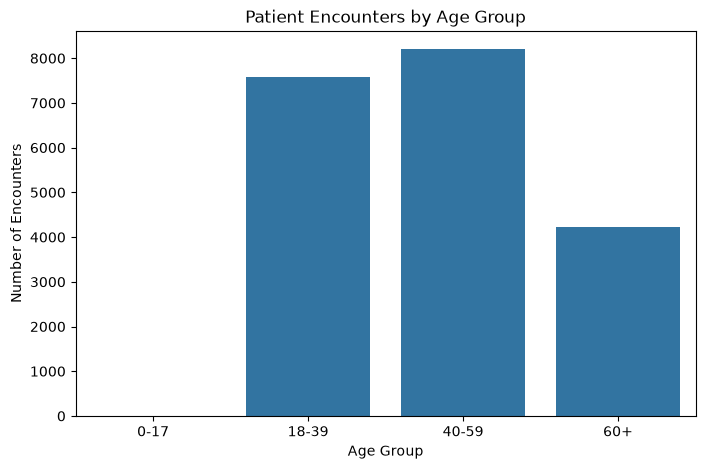

In [327]:
age_group_counts = analysis_df["Age_Group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title("Patient Encounters by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Encounters")

plt.show()

In [328]:
analysis_df["Waiting_Category"] = pd.cut(
    analysis_df["Waiting_Time_Min"],
    bins=[-1, 30, 60, float("inf")],
    labels=["Short", "Moderate", "Long"]
)

In [329]:
analysis_df["Waiting_Category"].value_counts().sort_index()

Waiting_Category
Short        6750
Moderate    11090
Long         2160
Name: count, dtype: int64

In [330]:
waiting_category_pct = (
    analysis_df["Waiting_Category"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

waiting_category_pct

Waiting_Category
Short       33.75
Moderate    55.45
Long        10.80
Name: proportion, dtype: float64

In [331]:
satisfaction_by_waiting = (
    analysis_df.groupby("Waiting_Category", observed=True)["Satisfaction_Score"]
    .mean()
)

satisfaction_by_waiting

Waiting_Category
Short       3.682963
Moderate    3.672949
Long        3.696296
Name: Satisfaction_Score, dtype: float64

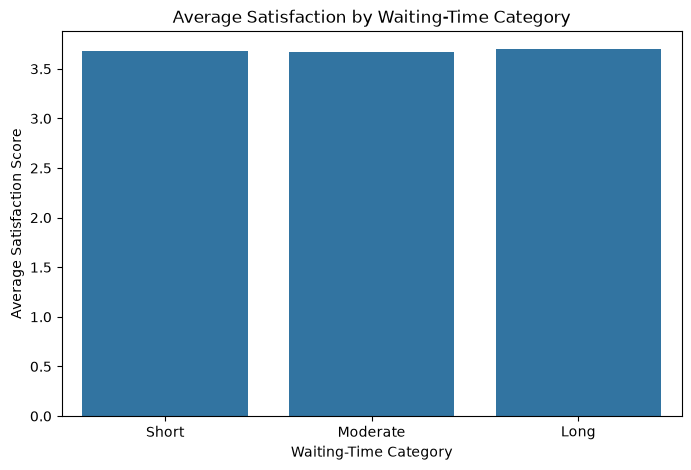

In [332]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=analysis_df,
    x="Waiting_Category",
    y="Satisfaction_Score",
    estimator="mean",
    errorbar=None
)

plt.title("Average Satisfaction by Waiting-Time Category")
plt.xlabel("Waiting-Time Category")
plt.ylabel("Average Satisfaction Score")

plt.show()

In [334]:
analysis_df["Cost_per_LOS_Day"] = (
    analysis_df["Treatment_Cost"]
    / analysis_df["Length_of_Stay"]
)

## 6.2 Cost per Length-of-Stay Day

In [341]:
analysis_df["Cost_per_LOS_Day"] = np.where(
    analysis_df["Length_of_Stay"] > 0,
    analysis_df["Treatment_Cost"] / analysis_df["Length_of_Stay"],
    np.nan
)

In [342]:
analysis_df["Cost_per_LOS_Day"].describe()

count     3561.000000
mean     12657.363017
std       9249.815602
min       3613.500000
25%       7081.250000
50%       9547.100000
75%      14501.500000
max      84172.000000
Name: Cost_per_LOS_Day, dtype: float64

In [343]:
np.isinf(analysis_df["Cost_per_LOS_Day"]).sum()

np.int64(0)

In [344]:
analysis_df["Cost_per_LOS_Day"].isna().sum()

np.int64(16439)

In [345]:
cost_per_day_department = (
    analysis_df.groupby("Department")["Cost_per_LOS_Day"]
    .mean()
    .sort_values(ascending=False)
)

cost_per_day_department

Department
Cardiology          15615.582507
Surgery             14816.354737
Orthopedics         12935.520178
Gynecology          12082.272960
Dermatology         11446.667248
General Medicine    11274.584001
Pediatrics          10809.796983
Name: Cost_per_LOS_Day, dtype: float64

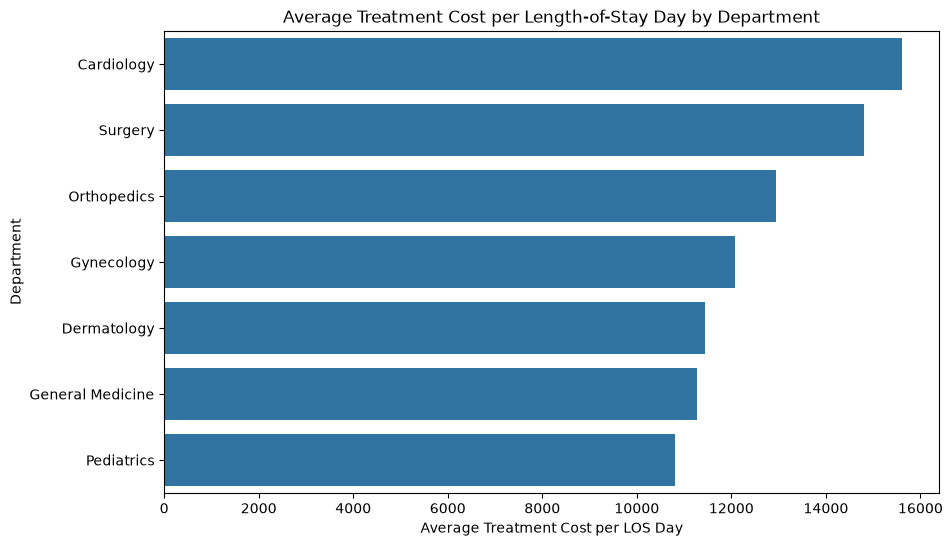

In [346]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=cost_per_day_department.values,
    y=cost_per_day_department.index
)

plt.title("Average Treatment Cost per Length-of-Stay Day by Department")
plt.xlabel("Average Treatment Cost per LOS Day")
plt.ylabel("Department")

plt.show()

# 7. 30-Day Readmission Analysis

In [347]:
readmission_rate = (
    analysis_df["Readmission_30_Days"].mean() * 100
)

readmission_rate

np.float64(7.03)

## 7.1 Readmission Patterns

In [349]:
readmission_by_department = (
    analysis_df.groupby("Department")["Readmission_30_Days"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

readmission_by_department

Department
Dermatology         8.485164
Pediatrics          7.213635
General Medicine    7.169374
Orthopedics         7.026307
Gynecology          6.958042
Cardiology          6.697108
Surgery             6.025408
Name: Readmission_30_Days, dtype: float64

In [350]:
readmission_by_age = (
    analysis_df.groupby("Age_Group", observed=True)["Readmission_30_Days"]
    .mean()
    .mul(100)
)

readmission_by_age

Age_Group
18-39     5.209020
40-59     6.609756
60+      11.121650
Name: Readmission_30_Days, dtype: float64

In [351]:
readmission_by_visit = (
    analysis_df.groupby("Visit_Type")["Readmission_30_Days"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

readmission_by_visit

Visit_Type
IPD    10.390340
OPD     6.302087
Name: Readmission_30_Days, dtype: float64

## 7.2 Readmission Comparison

In [355]:
readmission_summary = (
    analysis_df
    .groupby("Readmission_30_Days")[
        [
            "Length_of_Stay",
            "Treatment_Cost",
            "Number_of_Procedures"
        ]
    ]
    .mean()
)

readmission_summary

,Length_of_Stay,Treatment_Cost,Number_of_Procedures
Readmission_30_Days,,,
0,0.743251,25457.872002,1.512800
1,1.256046,28529.078947,1.475107


In [356]:
readmission_summary.T

Readmission_30_Days,0,1
Length_of_Stay,0.743251,1.256046
Treatment_Cost,25457.872002,28529.078947
Number_of_Procedures,1.512800,1.475107


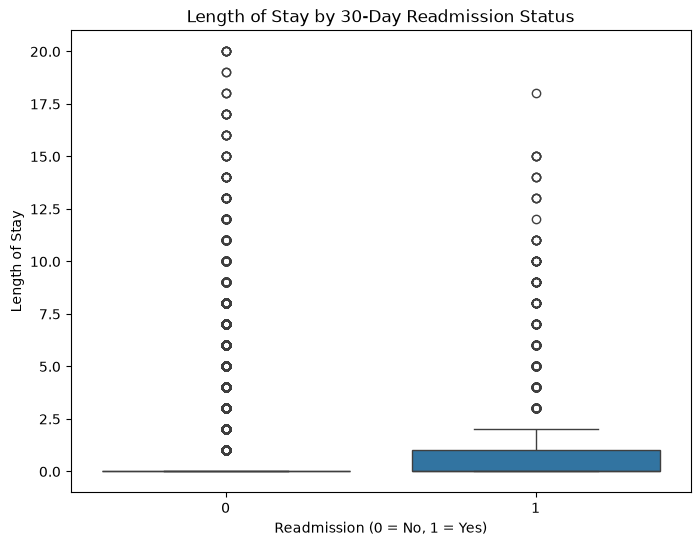

In [357]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_df,
    x="Readmission_30_Days",
    y="Length_of_Stay"
)

plt.title("Length of Stay by 30-Day Readmission Status")
plt.xlabel("Readmission (0 = No, 1 = Yes)")
plt.ylabel("Length of Stay")

plt.show()

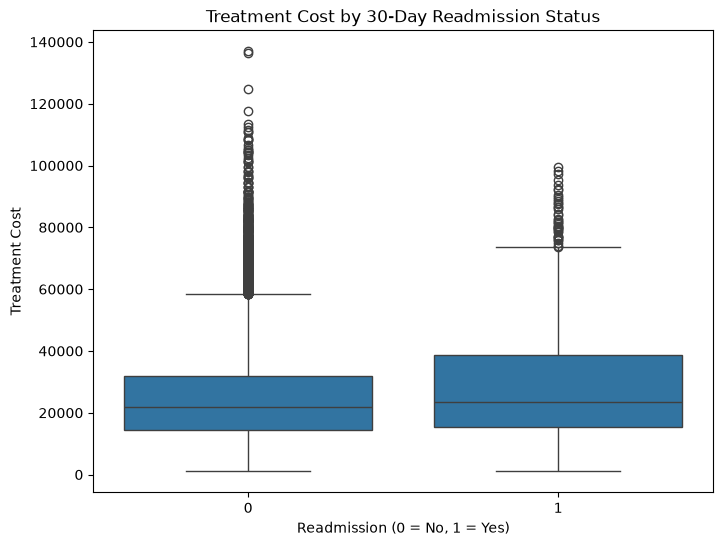

In [358]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=analysis_df,
    x="Readmission_30_Days",
    y="Treatment_Cost"
)

plt.title("Treatment Cost by 30-Day Readmission Status")
plt.xlabel("Readmission (0 = No, 1 = Yes)")
plt.ylabel("Treatment Cost")

plt.show()

# 8. Statistical Testing

In [359]:
los_no_readmission = analysis_df[
    analysis_df["Readmission_30_Days"] == 0
]["Length_of_Stay"]

los_readmission = analysis_df[
    analysis_df["Readmission_30_Days"] == 1
]["Length_of_Stay"]

## 8.1 Mann–Whitney U Test

In [361]:
from scipy.stats import mannwhitneyu

In [362]:
u_statistic, p_value = mannwhitneyu(
    los_no_readmission,
    los_readmission,
    alternative="two-sided"
)

u_statistic, p_value

(np.float64(11816980.0), np.float64(1.9894789841084334e-19))

## 8.2 Mann–Whitney U Test — Treatment Cost

In [364]:
cost_no_readmission = analysis_df[
    analysis_df["Readmission_30_Days"] == 0
]["Treatment_Cost"]

cost_readmission = analysis_df[
    analysis_df["Readmission_30_Days"] == 1
]["Treatment_Cost"]

In [365]:
u_cost, p_cost = mannwhitneyu(
    cost_no_readmission,
    cost_readmission,
    alternative="two-sided"
)

u_cost, p_cost

(np.float64(12007930.0), np.float64(3.4785962787467403e-07))

## 8.3 Mann–Whitney U Test — Number of Procedures

In [367]:
procedures_no_readmission = analysis_df[
    analysis_df["Readmission_30_Days"] == 0
]["Number_of_Procedures"]

procedures_readmission = analysis_df[
    analysis_df["Readmission_30_Days"] == 1
]["Number_of_Procedures"]

In [368]:
u_procedures, p_procedures = mannwhitneyu(
    procedures_no_readmission,
    procedures_readmission,
    alternative="two-sided"
)

u_procedures, p_procedures

(np.float64(13357729.5), np.float64(0.15616012918811398))

# 9. Predictive Modeling

In [370]:
features = [
    "Age",
    "Gender",
    "Department",
    "Visit_Type",
    "Length_of_Stay",
    "Treatment_Cost",
    "Number_of_Procedures",
    "ICU_Admission"
]

X = analysis_df[features]
y = analysis_df["Readmission_30_Days"]

## 9.1 Feature Preparation & Encoding

In [373]:
categorical_features = [
    "Gender",
    "Department",
    "Visit_Type",
    "ICU_Admission"
]

numeric_features = [
    "Age",
    "Length_of_Stay",
    "Treatment_Cost",
    "Number_of_Procedures"
]

In [374]:
from sklearn.preprocessing import OneHotEncoder

In [375]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

In [376]:
from sklearn.compose import ColumnTransformer

In [377]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", encoder, categorical_features)
    ],
    remainder="passthrough"
)

In [378]:
X_encoded = preprocessor.fit_transform(X)

## 9.2 Train-Test Split

In [382]:
from sklearn.model_selection import train_test_split

In [383]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## 9.3 Baseline Logistic Regression

In [385]:
from sklearn.linear_model import LogisticRegression

In [386]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [387]:
logistic_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [388]:
y_pred = logistic_model.predict(X_test)

In [390]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [391]:
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.92975

In [392]:
precision = precision_score(y_test, y_pred)

precision

C:\Users\Niharika\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0.0

In [393]:
recall = recall_score(y_test, y_pred)

recall

0.0

In [394]:
f1 = f1_score(y_test, y_pred)

f1

0.0

In [395]:
model_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

model_metrics

,Metric,Score
0,Accuracy,0.92975
1,Precision,0.00000
2,Recall,0.00000
3,F1 Score,0.00000


In [396]:
from sklearn.metrics import confusion_matrix

In [397]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[3719,    0],
       [ 281,    0]])

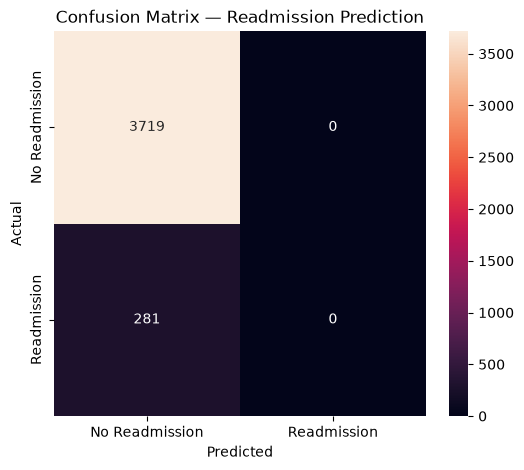

In [398]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Readmission", "Readmission"],
    yticklabels=["No Readmission", "Readmission"]
)

plt.title("Confusion Matrix — Readmission Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 9.4 Class-Balanced Logistic Regression

In [399]:
logistic_balanced = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

In [400]:
logistic_balanced.fit(X_train, y_train)

C:\Users\Niharika\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [401]:
y_pred_balanced = logistic_balanced.predict(X_test)

In [402]:
cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)

cm_balanced

array([[2311, 1408],
       [ 127,  154]])

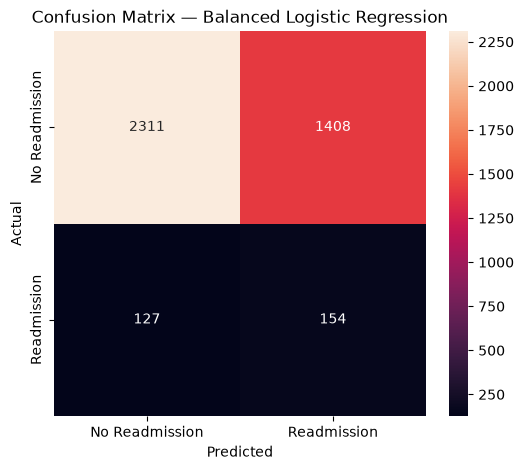

In [403]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    xticklabels=["No Readmission", "Readmission"],
    yticklabels=["No Readmission", "Readmission"]
)

plt.title("Confusion Matrix — Balanced Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 9.5 ROC-AUC Analysis

In [404]:
y_prob = logistic_balanced.predict_proba(X_test)[:, 1]

In [405]:
from sklearn.metrics import roc_auc_score, roc_curve

In [406]:
auc_score = roc_auc_score(y_test, y_prob)

auc_score

0.6076711012699048

In [407]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

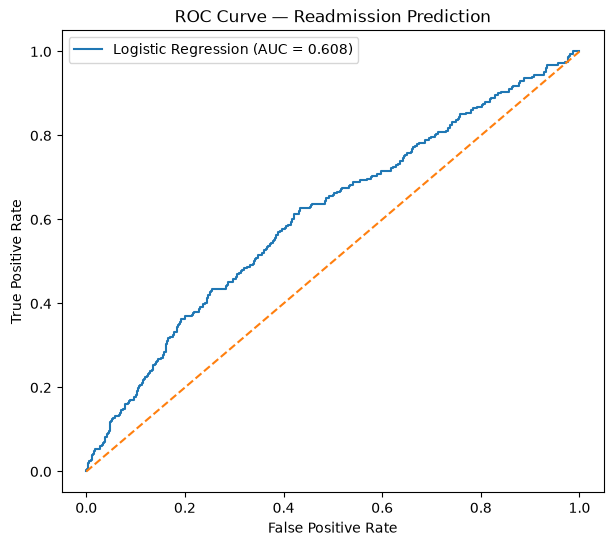

In [408]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Readmission Prediction")
plt.legend()

plt.show()

## 9.6 Random Forest

In [409]:
from sklearn.ensemble import RandomForestClassifier

In [410]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [411]:
random_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [412]:
rf_pred = random_forest.predict(X_test)

In [413]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)

rf_accuracy, rf_precision, rf_recall, rf_f1

(0.8845, 0.08294930875576037, 0.06405693950177936, 0.07228915662650602)

In [414]:
rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm

array([[3520,  199],
       [ 263,   18]])

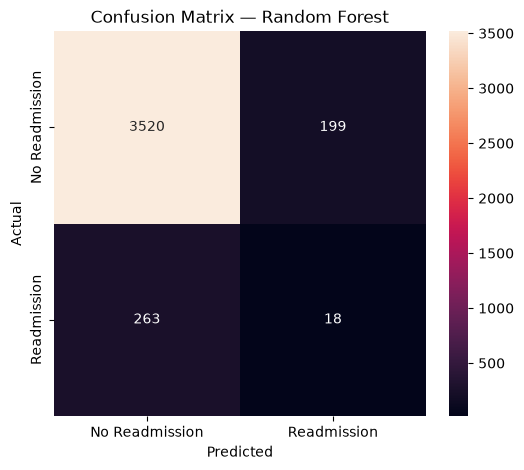

In [415]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Readmission", "Readmission"],
    yticklabels=["No Readmission", "Readmission"]
)

plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 9.7 Model Comparison

In [416]:
comparison_df = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, y_pred_balanced),
        rf_accuracy
    ],
    "Precision": [
        precision,
        precision_score(y_test, y_pred_balanced, zero_division=0),
        rf_precision
    ],
    "Recall": [
        recall,
        recall_score(y_test, y_pred_balanced, zero_division=0),
        rf_recall
    ],
    "F1 Score": [
        f1,
        f1_score(y_test, y_pred_balanced, zero_division=0),
        rf_f1
    ]
})

comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,Original Logistic Regression,0.930,0.000,0.000,0.000
1,Balanced Logistic Regression,0.616,0.099,0.548,0.167
2,Random Forest,0.884,0.083,0.064,0.072


## 9.8 Feature Importance

In [417]:
feature_names = preprocessor.get_feature_names_out()

In [419]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest.feature_importances_
})

In [420]:
importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

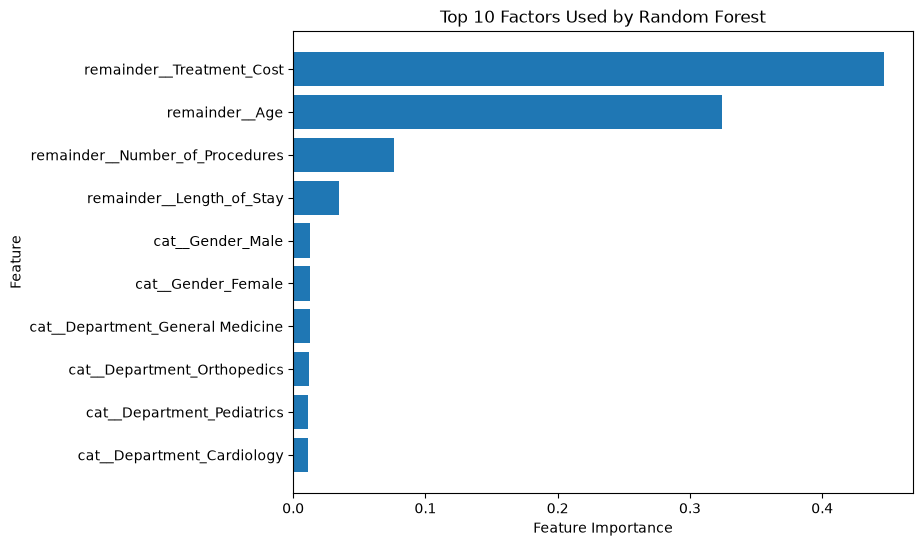

In [422]:
top_features = importance_df.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Factors Used by Random Forest")

plt.show()

In [424]:
rf_prob = random_forest.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)

rf_auc

0.5608972488108099

In [425]:
balanced_auc = roc_auc_score(y_test, y_prob)

balanced_auc

0.6076711012699048

In [426]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Original Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        accuracy_score(y_test, y_pred_balanced),
        rf_accuracy
    ],
    "Precision": [
        precision,
        precision_score(y_test, y_pred_balanced, zero_division=0),
        rf_precision
    ],
    "Recall": [
        recall,
        recall_score(y_test, y_pred_balanced, zero_division=0),
        rf_recall
    ],
    "F1 Score": [
        f1,
        f1_score(y_test, y_pred_balanced, zero_division=0),
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_model.predict_proba(X_test)[:, 1]),
        balanced_auc,
        rf_auc
    ]
})

final_model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Original Logistic Regression,0.930,0.000,0.000,0.000,0.607
1,Balanced Logistic Regression,0.616,0.099,0.548,0.167,0.608
2,Random Forest,0.884,0.083,0.064,0.072,0.561


# 10. Executive Summary

In [427]:
final_findings = pd.DataFrame({
    "Area": [
        "30-Day Readmission",
        "Length of Stay",
        "Predictive Modeling",
        "Balanced Model",
        "Key Feature"
    ],
    "Finding": [
        "7.03% of encounters resulted in 30-day readmission",
        "LOS differed significantly between readmitted and non-readmitted encounters",
        "Original Logistic Regression had high accuracy but 0% recall",
        "Balanced Logistic Regression achieved approximately 55% recall",
        "Treatment Cost was the most influential Random Forest feature"
    ],
    "Management_Implication": [
        "Readmission is a minority but important outcome",
        "LOS warrants further investigation as a risk indicator",
        "Accuracy alone is misleading for this imbalanced outcome",
        "Risk screening can identify a portion of readmissions but creates false positives",
        "High-cost encounters warrant further investigation for readmission-risk patterns"
    ]
})

final_findings

,Area,Finding,Management_Implication
0,30-Day Readmission,7.03% of encounters resulted in 30-day readmis...,Readmission is a minority but important outcome
1,Length of Stay,LOS differed significantly between readmitted ...,LOS warrants further investigation as a risk i...
2,Predictive Modeling,Original Logistic Regression had high accuracy...,Accuracy alone is misleading for this imbalanc...
3,Balanced Model,Balanced Logistic Regression achieved approxim...,Risk screening can identify a portion of readm...
4,Key Feature,Treatment Cost was the most influential Random...,High-cost encounters warrant further investiga...


In [428]:
readmission_rate = (
    analysis_df["Readmission_30_Days"].mean() * 100
)

avg_treatment_cost = analysis_df["Treatment_Cost"].mean()

avg_los = analysis_df["Length_of_Stay"].mean()

avg_satisfaction = analysis_df["Satisfaction_Score"].mean()

readmission_rate, avg_treatment_cost, avg_los, avg_satisfaction

(np.float64(7.03),
 np.float64(25673.77785),
 np.float64(0.7793),
 np.float64(3.67885))

In [429]:
executive_kpis = pd.DataFrame({
    "KPI": [
        "30-Day Readmission Rate",
        "Average Treatment Cost",
        "Average Length of Stay",
        "Average Satisfaction Score"
    ],
    "Value": [
        f"{readmission_rate:.2f}%",
        f"{avg_treatment_cost:,.2f}",
        f"{avg_los:.2f} days",
        f"{avg_satisfaction:.2f}"
    ]
})

executive_kpis

,KPI,Value
0,30-Day Readmission Rate,7.03%
1,Average Treatment Cost,"25,673.78"
2,Average Length of Stay,0.78 days
3,Average Satisfaction Score,3.68


In [430]:
group_summary = analysis_df.groupby(
    "Readmission_30_Days"
)[[
    "Age",
    "Length_of_Stay",
    "Treatment_Cost",
    "Number_of_Procedures"
]].mean()

group_summary

,Age,Length_of_Stay,Treatment_Cost,Number_of_Procedures
Readmission_30_Days,,,,
0,45.140959,0.743251,25457.872002,1.512800
1,50.798009,1.256046,28529.078947,1.475107


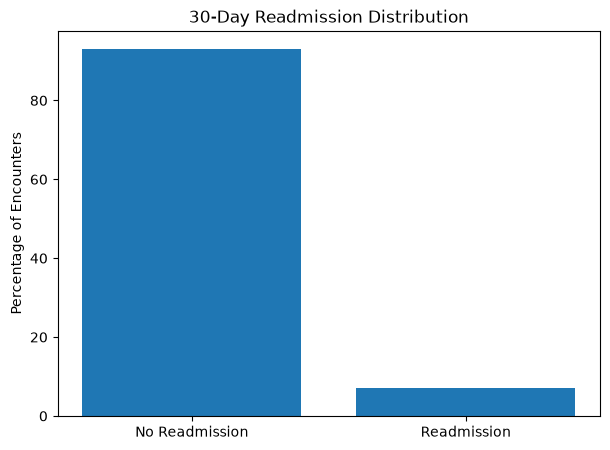

In [431]:
readmission_summary = (
    analysis_df["Readmission_30_Days"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Readmission", "Readmission"],
    readmission_summary.values
)

plt.ylabel("Percentage of Encounters")
plt.title("30-Day Readmission Distribution")

plt.show()

## 10.1 Chi-Square Test — ICU Admission & Readmission

In [432]:
icu_table = pd.crosstab(
    analysis_df["ICU_Admission"],
    analysis_df["Readmission_30_Days"]
)

icu_table

Readmission_30_Days,0,1
ICU_Admission,,
No,17110,1234
Yes,1484,172


In [433]:
from scipy.stats import chi2_contingency

In [434]:
chi2, p_value, dof, expected = chi2_contingency(icu_table)

chi2, p_value

(np.float64(30.564394031349217), np.float64(3.229668119328505e-08))

In [435]:
icu_readmission_rate = (
    analysis_df.groupby("ICU_Admission")["Readmission_30_Days"]
    .mean() * 100
)

icu_readmission_rate

ICU_Admission
No      6.726995
Yes    10.386473
Name: Readmission_30_Days, dtype: float64

# 11. Key Findings

# Key Findings

- 30-day readmission rate was approximately 7.03%.
- Length of Stay differed significantly between readmitted and
  non-readmitted encounters.
- ICU admission was significantly associated with 30-day readmission.
- The balanced Logistic Regression model substantially improved
  readmission recall compared with the baseline model.
- Treatment Cost and Age were the most influential features in the
  Random Forest model.

# 12. Healthcare Management Recommendations

# Healthcare Management Recommendations

- Consider targeted post-discharge follow-up for higher-risk patients.
- Investigate high-cost encounters for patterns associated with
  subsequent readmission.
- Consider enhanced discharge planning for higher-risk patient groups.
- Evaluate readmission models using recall, precision, F1-score and
  ROC-AUC rather than accuracy alone.
- Conduct further clinical and temporal validation before operational
  deployment.

# 13. Limitations

# Limitations

- The dataset represents a specific set of hospital encounters and may
  not be fully generalizable to other hospitals or patient populations.

- The analysis identifies statistical associations and predictive
  patterns but does not establish causal relationships.

- The readmission outcome is highly imbalanced, which makes model
  evaluation challenging and can affect predictive performance.

- The balanced Logistic Regression model improved recall but produced
  a relatively large number of false-positive predictions.

- The predictive models have not undergone external or temporal
  validation.

- The current models should therefore be considered analytical
  prototypes rather than clinically validated decision-support tools.

- Further threshold optimization, clinical validation, and assessment
  of real-world operational impact would be required before deployment.

# 14. Conclusion

# Conclusion

This project analyzed hospital encounter data to evaluate patient
experience, operational performance, treatment utilization, cost,
Length of Stay, and 30-day readmission.

The analysis demonstrated that readmission is a relatively uncommon
outcome and that class imbalance can make overall accuracy misleading.
Statistical analysis identified a significant difference in Length of
Stay between readmitted and non-readmitted encounters and a significant
association between ICU admission and 30-day readmission.

Machine-learning analysis showed that the class-balanced Logistic
Regression model substantially improved recall compared with the
baseline model, while the Random Forest model achieved higher overall
accuracy but identified fewer actual readmissions.

Treatment Cost and Age were the most influential features in the
Random Forest model.

Overall, the project demonstrates how healthcare analytics can be used
to identify operational patterns, investigate patient outcomes, and
support readmission risk stratification. Further threshold
optimization, clinical validation, and external or temporal validation
would be required before using the predictive model for operational
decision-making.